In [3]:
# Load functions

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats





In [5]:
# Define the project root and data directory

CURRENT = Path.cwd()

if  CURRENT.name == "notebooks":
    PROJECT_ROOT = CURRENT.parent
else:
    PROJECT_ROOT = CURRENT

DATA_DIR = PROJECT_ROOT / "data"

print("Current directory:", CURRENT)
print("Project root directory:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Data exists:", DATA_DIR.exists())

Current directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/notebooks
Project root directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Data exists: True


In [9]:
# Load the dataset

df = pd.read_csv(DATA_DIR / "cs-training.csv")
df.head()
drop_cols = ["Unnamed: 0"]
df.drop(columns=drop_cols, inplace=True)
df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# Remove the unnamed index column if it exists
df = df.loc[:, ~df.columns.str.contains("Unnamed: 0")]
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [21]:
# Basic data structure review
print("Data shape:", df.shape)
print("Data types:\n", df.dtypes)
print("Duplicated rows:", df.duplicated().sum())
print("Target variable distribution:\n", df["SeriousDlqin2yrs"].value_counts())
print("Target variable distribution (normalized):\n", df["SeriousDlqin2yrs"].value_counts(normalize=True))
print("Percentile distributions:", df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)
print("Missing values:\n", df.isnull().sum())
df.info()

Data shape: (150000, 11)
Data types:
 SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object
Duplicated rows: 609
Target variable distribution:
 SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
Target variable distribution (normalized):
 SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64
Percentile distributions:                                          count         mean           std  \
SeriousDlqin2yrs                      150000.0     0.066840      0.249746   
R

## Data Structure Review ##

1. Data Size and Structure

The dataset contains 150,000 observations and 11 variables, which is sufficient scale for robust supervised credit risk modeling.

Variables are predominantly numeric, simplifying baseline modeling approaches such as logistic regression, tree ensembles, and gradient boosting without requiring extensive categorical encoding.

2. Duplicate Records

A total of 609 duplicate rows were identified.

This requires investigation before modeling. Duplicate records may arise from:
- repeated customer snapshots
- accidental file duplication
- multiple applications
- data extraction issues

If duplicates are unintended, retaining them can bias model estimation and artificially overweight repeated borrower profiles.

Recommended Action:
- For the current modeling exercise, remove exact duplicate rows.
- In a production environment, investigate whether duplicates represent true repeat customers or extract issues before deletion.

3. Integrity of Target Variable

The target variable is cleanly binary with no missing values:

- Non-event: 93.32%
- Event: 6.68%

This confirms a valid supervised learning target with expected class imbalance for consumer credit portfolios.

Recommended Action:
- Retain target as-is.
- During modeling, avoid relying on raw accuracy and prioritize AUC, KS, Recall, Precision, and calibration metrics.

4. Distribution Analysis

4a. Age

Minimum age = 0
Maximum age = 109

Age = 0 is invalid and indicates data quality issues or placeholder coding.
Very high ages (e.g., 109) may be valid but should be reviewed.

Recommended Action:
- Set age < 18 to missing or exclude those records.
- Cap upper tail at 99th percentile or business-approved threshold.
- Consider age banding for logistic regression stability.

4b. Revolving Utilization

Mean = 6.05
99th percentile = 1.09
Max = 50,708

Most borrowers lie below ~1 utilization, but extreme observations massively distort the mean.
Values above 1 may be possible (over-limit / fees), but 50,708 strongly suggests outliers, denominator issues, or data errors.

Recommended Action:
- Winsorize at upper percentile (99th or 99.5th percentile).
- Consider log or capped transformation.
- Preserve a high-utilization flag for stressed borrowers.
- Validate whether values >1 should be retained or capped.

4c. Debt Ratio

Median = 0.37
95th = 2449
Max = 329,664

DebtRatio exhibits severe right-tail distribution. Median values are reasonable, while upper tail values look extreme and likely reflect zero or near-zero income or reporting errors.

Recommended Action:
- Winsorize upper tail aggressively (e.g., 99th percentile).
- Consider separate indicator for extreme debt burden.
- Investigate whether zero income records are driving inflated ratios.
- Apply log/capped transformation if used in linear models.

4d. Monthly Income

Median = 5,400
99th = 25,000
Max = 3,008,750

Income distribution appears broadly plausible through upper percentiles, but extreme max values suggest rare outliers requiring review/capping. Also, missing value treatment required.

Recommended Action:
- Create income_missing_flag.
- Impute missing values using median or segment-based logic.
- Winsorize high-end tail (99th percentile or policy threshold).
- Consider log transformation due to right skew.

4e. Times 90 Days Late / Delinquency Variables

30-59 max = 98
60-89 max = 98
90+ max = 98

Repeated maximum values of 98 across delinquency variables suggest coded sentinel values rather than genuine delinquency counts. Most likely: 96 / 98 = special bureau codes.

Recommended Action:
- Frequency-test values 96 and 98 across delinquency fields.
- Recode special values to missing or business-approved capped values.
- Create special-code flags if operationally meaningful.
- Cap legitimate delinquency counts at sensible upper threshold.
- Review monotonic relationship to bad rate after recoding.

5. Overall Data Quality Conclusion

The dataset is suitable for credit risk model development, but requires structured preprocessing before estimation. Key remediation themes include:

- duplicate removal
- missing value treatment
- outlier capping
- special code remediation
- variable transformation
- class imbalance-aware evaluation

These steps should be completed and documented prior to final model training.

Value counts:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Value counts (normalized):
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


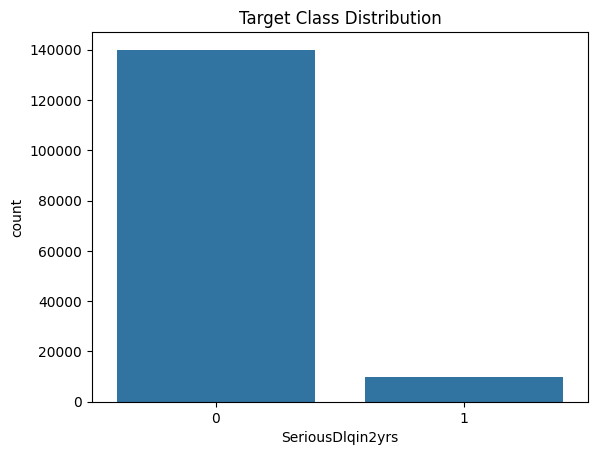

In [26]:
# Target variable review

print("Value counts:")
print(df["SeriousDlqin2yrs"].value_counts())
print("\nValue counts (normalized):")
print(df["SeriousDlqin2yrs"].value_counts(normalize=True))

sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Target Class Distribution")
plt.show()

### Target Variable Review: SeriousDlqin2yrs

The dependent variable represents whether a borrower experienced serious delinquency within the subsequent two-year period.

- Total records: 150,000
- Event count: 10,026
- Event rate: 6.68%

1. The dataset exhibits class imbalance, with delinquency events representing a minority of observations.
2. This imbalance is expected in credit risk portfolios.
3. Standard accuracy is not an appropriate primary performance metric, since a naïve model predicting all observations as non-events would still achieve high accuracy.
4. Model evaluation should use rank-ordering and event discrimination metrics:
   - AUC / ROC
   - KS Statistic
   - Precision / Recall
   - Recall at operational thresholds
   - Calibration
5. Depending on modeling approach, class imbalance mitigation techniques may be considered:
   - Class weights
   - Oversampling / undersampling
   - Threshold optimization
   - Cost-sensitive learning

                                      missing_count  missing_percent
MonthlyIncome                                 29731        19.820667
NumberOfDependents                             3924         2.616000
SeriousDlqin2yrs                                  0         0.000000
RevolvingUtilizationOfUnsecuredLines              0         0.000000
age                                               0         0.000000
NumberOfTime30-59DaysPastDueNotWorse              0         0.000000
DebtRatio                                         0         0.000000
NumberOfOpenCreditLinesAndLoans                   0         0.000000
NumberOfTimes90DaysLate                           0         0.000000
NumberRealEstateLoansOrLines                      0         0.000000
NumberOfTime60-89DaysPastDueNotWorse              0         0.000000


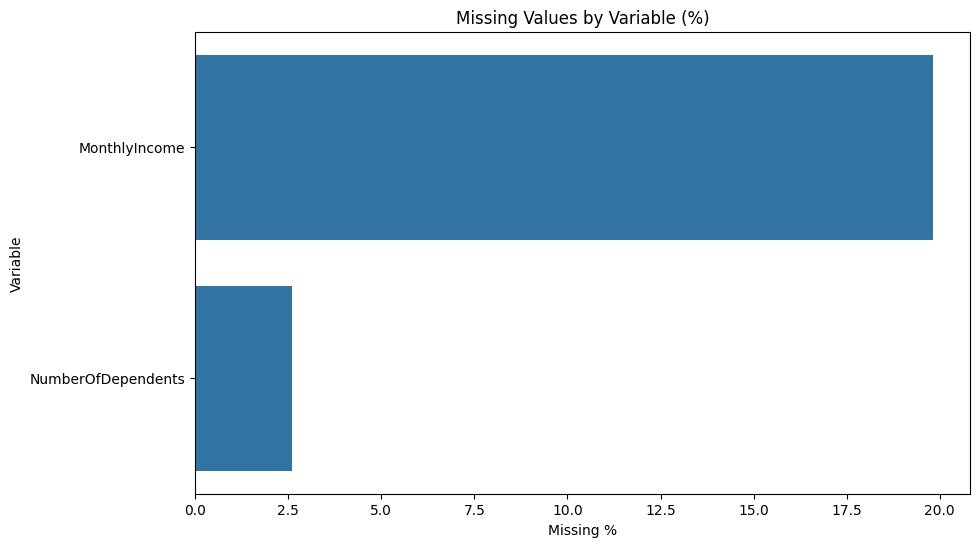

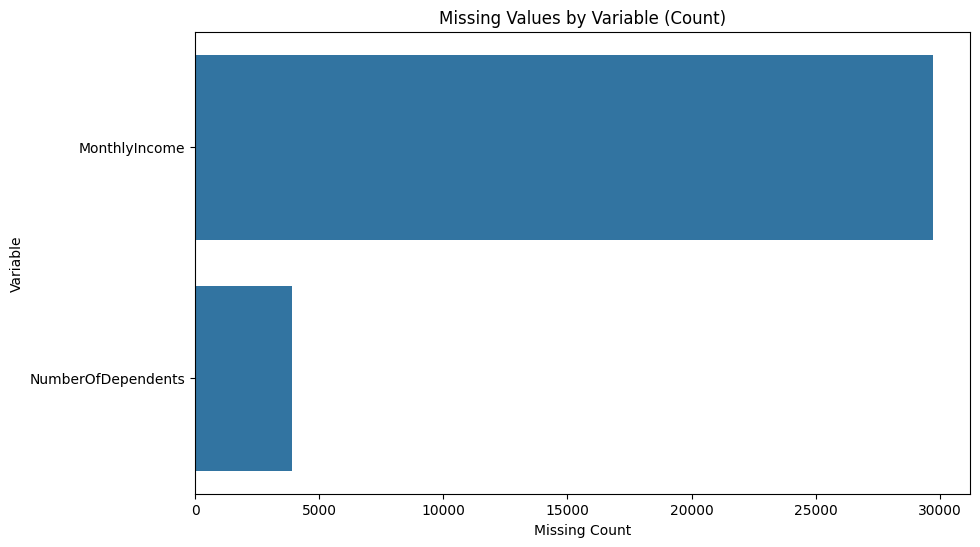

Missing values (MonthlyIncome) by target class: MonthlyIncome
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64
Missing values (NumberOfDependents) by target class: NumberOfDependents
False    0.067410
True     0.045617
Name: SeriousDlqin2yrs, dtype: float64


In [27]:
# Check for missing values

missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values("missing_percent", ascending=False)

print(missing)

missing_plot = missing[missing["missing_count"] > 0]

# Visualize missing percentages
plt.figure(figsize = (10, 6))
sns.barplot(data = missing_plot.reset_index(),
            x = "missing_percent",
            y = "index"
            )

plt.title("Missing Values by Variable (%)")
plt.xlabel("Missing %")
plt.ylabel("Variable")
plt.show()

#Visualize missing values

plt.figure(figsize = (10, 6))
sns.barplot(data = missing_plot.reset_index(),
            x = "missing_count",
            y = "index"
            )

plt.title("Missing Values by Variable (Count)")
plt.xlabel("Missing Count")
plt.ylabel("Variable")
plt.show()

# Missing values vs target variable

print("Missing values (MonthlyIncome) by target class:", df.groupby(df['MonthlyIncome'].isnull())['SeriousDlqin2yrs'].mean())
print("Missing values (NumberOfDependents) by target class:", df.groupby(df['NumberOfDependents'].isnull())['SeriousDlqin2yrs'].mean())


## Missing Data Review

Only two variables have missing values:

1. MonthlyIncome: 29,731 records (19.82%)
2. NumberOfDependents: 3,924 records (2.62%)

### Interpretation

Missingness is concentrated within 2 variablesrather than widespread, which is favorable from a model governance perspective because imputation is only required for two variables.

### MonthlyIncome

MonthlyIncome has material missingness (~20%), making it a key preprocessing decision point.

Observed delinquency rates:
- Income present: 6.95%
- Income missing: 5.61%

This indicates that records with missing income have a lower observed bad rate than records with populated income.

### NumberOfDependents

NumberOfDependents has modest missingness (2.62%), but missing records display a lower observed delinquency rate (4.56%) than populated records (6.74%).
This suggests the missing values may not be purely random and could reflect borrower segment differences or operational capture patterns.
Although lower priority than MonthlyIncome due to smaller volume, the variable warrants structured treatment rather than simple deletion.

### Implications

Missing income does not appear random and may represent a structurally different borrower segment rather than simple data noise.
Given the volume and non-random nature of missingness, dropping these records would likely discard signal and distort portfolio representation.

Preferred treatment candidates:
1. Median imputation + missing flag
2. Segment-based imputation
3. Model-based imputation (probably only for MonthlyIncome given it's high count of missing values)

A separate missing indicator will also be added to preserve informational content.

In [31]:
# Outlier and anomaly screening with caveats

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []

for col in numeric_cols:
    col_data = df[col].dropna()

    q01 = col_data.quantile(0.01)
    q05 = col_data.quantile(0.05)
    q25 = col_data.quantile(0.25)
    q50 = col_data.quantile(0.50)
    q75 = col_data.quantile(0.75)
    q95 = col_data.quantile(0.95)
    q99 = col_data.quantile(0.99)
    q995 = col_data.quantile(0.995)
    q999 = col_data.quantile(0.999)

    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr

    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]

    unique_count = col_data.nunique()
    zero_pct = (col_data == 0).mean() * 100

    # Variable type / caveat classification
    if col == "SeriousDlqin2yrs":
        variable_type = "binary_target"
        iqr_comment = "IQR outlier rule not applicable to binary target."
    elif unique_count <= 25 and zero_pct > 50:
        variable_type = "zero_inflated_count"
        iqr_comment = "IQR may over-flag because variable is discrete and zero-inflated."
    elif iqr == 0:
        variable_type = "low_variation_or_zero_inflated"
        iqr_comment = "IQR is zero; generic IQR rule is not reliable."
    elif q99 > q50 * 10 if q50 != 0 else q99 > 0:
        variable_type = "highly_skewed_numeric"
        iqr_comment = "Use percentile/business caps rather than relying only on IQR."
    else:
        variable_type = "numeric"
        iqr_comment = "IQR screen usable as a rough diagnostic, not automatic treatment."

    outlier_summary.append({
        "variable": col,
        "variable_type": variable_type,
        "count": len(col_data),
        "missing_count": df[col].isna().sum(),
        "missing_pct": df[col].isna().mean() * 100,
        "unique_count": unique_count,
        "zero_pct": zero_pct,
        "min": col_data.min(),
        "p01": q01,
        "p05": q05,
        "p25": q25,
        "median": q50,
        "p75": q75,
        "p95": q95,
        "p99": q99,
        "p995": q995,
        "p999": q999,
        "max": col_data.max(),
        "iqr": iqr,
        "iqr_lower_bound": lower_bound,
        "iqr_upper_bound": upper_bound,
        "iqr_outlier_count": len(outliers),
        "iqr_outlier_pct": len(outliers) / len(col_data) * 100,
        "pct_above_p99": (col_data > q99).mean() * 100,
        "comment": iqr_comment
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by=["variable_type", "iqr_outlier_pct"],
    ascending=[True, False]
)

,variable,variable_type,count,missing_count,missing_pct,unique_count,zero_pct,min,p01,p05,...,p995,p999,max,iqr,iqr_lower_bound,iqr_upper_bound,iqr_outlier_count,iqr_outlier_pct,pct_above_p99,comment
0,SeriousDlqin2yrs,binary_target,150000,0,0.000000,2,93.316000,0.0,0.0,0.000000,...,1.000000,1.000,1.0,0.000000,0.000000,0.000000,10026,6.684000,0.000000,IQR outlier rule not applicable to binary target.
4,DebtRatio,highly_skewed_numeric,150000,0,0.000000,114194,2.742000,0.0,0.0,0.004329,...,6186.010000,10613.074,329664.0,0.693180,-0.864696,1.908024,31311,20.874000,1.000000,Use percentile/business caps rather than relyi...
5,MonthlyIncome,numeric,120269,29731,19.820667,13594,1.358621,0.0,0.0,1300.000000,...,35000.000000,78395.748,3008750.0,4849.000000,-3873.500000,15522.500000,4879,4.056739,0.971156,"IQR screen usable as a rough diagnostic, not a..."
6,NumberOfOpenCreditLinesAndLoans,numeric,150000,0,0.000000,58,1.258667,0.0,0.0,2.000000,...,27.000000,34.000,58.0,6.000000,-4.000000,20.000000,3980,2.653333,0.984000,"IQR screen usable as a rough diagnostic, not a..."
8,NumberRealEstateLoansOrLines,numeric,150000,0,0.000000,28,37.458667,0.0,0.0,0.000000,...,6.000000,9.000,54.0,2.000000,-3.000000,5.000000,793,0.528667,0.988000,"IQR screen usable as a rough diagnostic, not a..."
1,RevolvingUtilizationOfUnsecuredLines,numeric,150000,0,0.000000,125728,7.252000,0.0,0.0,0.000000,...,1.366269,1571.006,50708.0,0.529179,-0.763901,1.352814,763,0.508667,1.000000,"IQR screen usable as a rough diagnostic, not a..."
2,age,numeric,150000,0,0.000000,86,0.000667,0.0,24.0,29.000000,...,89.000000,94.000,109.0,22.000000,8.000000,96.000000,46,0.030667,0.850667,"IQR screen usable as a rough diagnostic, not a..."
3,NumberOfTime30-59DaysPastDueNotWorse,zero_inflated_count,150000,0,0.000000,16,84.012000,0.0,0.0,0.000000,...,5.000000,98.000,98.0,0.000000,0.000000,0.000000,23982,15.988000,0.566667,IQR may over-flag because variable is discrete...
10,NumberOfDependents,zero_inflated_count,146076,3924,2.616000,13,59.490950,0.0,0.0,0.000000,...,5.000000,6.000,20.0,1.000000,-1.500000,2.500000,13336,9.129494,0.678414,IQR may over-flag because variable is discrete...
7,NumberOfTimes90DaysLate,zero_inflated_count,150000,0,0.000000,19,94.441333,0.0,0.0,0.000000,...,4.000000,98.000,98.0,0.000000,0.000000,0.000000,8338,5.558667,0.582000,IQR may over-flag because variable is discrete...


A generic IQR-based outlier screen was calculated for diagnostic purposes only. However, this dataset contains binary, zero-inflated count, and highly skewed financial variables. Therefore, IQR flags should not be interpreted as automatic exclusions. Final treatment decisions will use variable-specific business logic, percentile analysis, and special-code review.


In [32]:
# Distribution diagnostics
# continuous variables

cont_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cont_cols.remove("SeriousDlqin2yrs")

for col in cont_cols:
    print(f"Variable: {col}")
    print(df[col].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    print()

Variable: RevolvingUtilizationOfUnsecuredLines
0.01    0.000000
0.05    0.000000
0.25    0.029867
0.50    0.154181
0.75    0.559046
0.95    1.000000
0.99    1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Variable: age
0.01    24.0
0.05    29.0
0.25    41.0
0.50    52.0
0.75    63.0
0.95    78.0
0.99    87.0
Name: age, dtype: float64

Variable: NumberOfTime30-59DaysPastDueNotWorse
0.01    0.0
0.05    0.0
0.25    0.0
0.50    0.0
0.75    0.0
0.95    2.0
0.99    4.0
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

Variable: DebtRatio
0.01       0.000000
0.05       0.004329
0.25       0.175074
0.50       0.366508
0.75       0.868254
0.95    2449.000000
0.99    4979.040000
Name: DebtRatio, dtype: float64

Variable: MonthlyIncome
0.01        0.0
0.05     1300.0
0.25     3400.0
0.50     5400.0
0.75     8249.0
0.95    14587.6
0.99    25000.0
Name: MonthlyIncome, dtype: float64

Variable: NumberOfOpenCreditLinesAndLoans
0.01     0.0
0.05     2.0
0.25     5.0
0.50

Percentile analysis indicates that most variables have economically plausible central distributions, with anomalies concentrated in a few fields.

Primary preprocessing attention should focus on:

1. DebtRatio – extreme right-tail distortion
2. RevolvingUtilizationOfUnsecuredLines – rare high-tail values
3. MonthlyIncome – missingness and moderate tail skew
4. Delinquency variables – likely special code values (96/98)
5. Age – invalid zero values

Several count variables such as open credit lines, real estate loans, and dependents appear broadly stable through the 99th percentile.

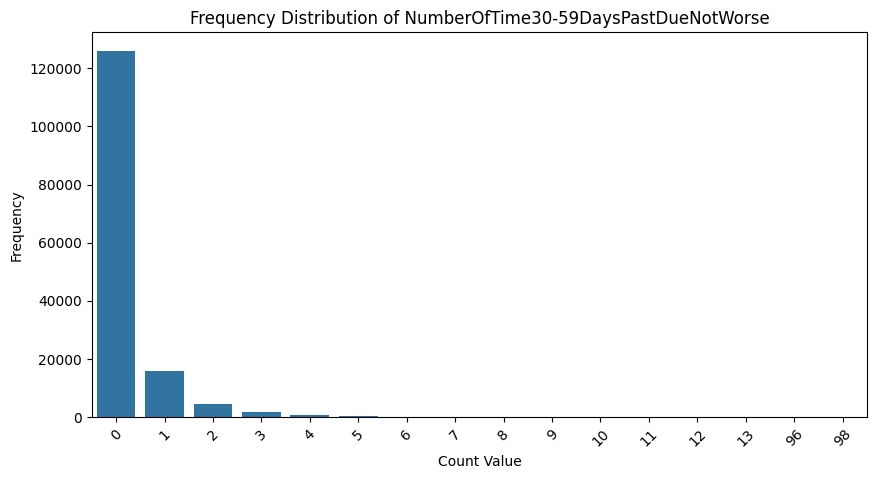

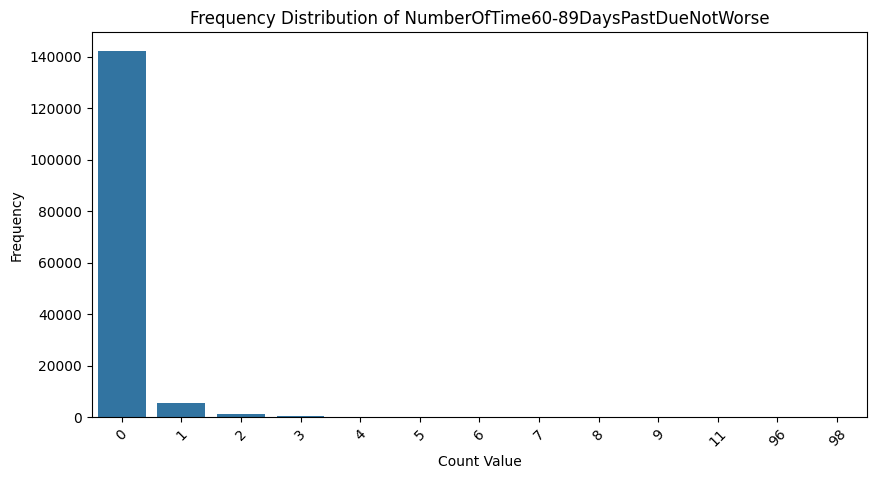

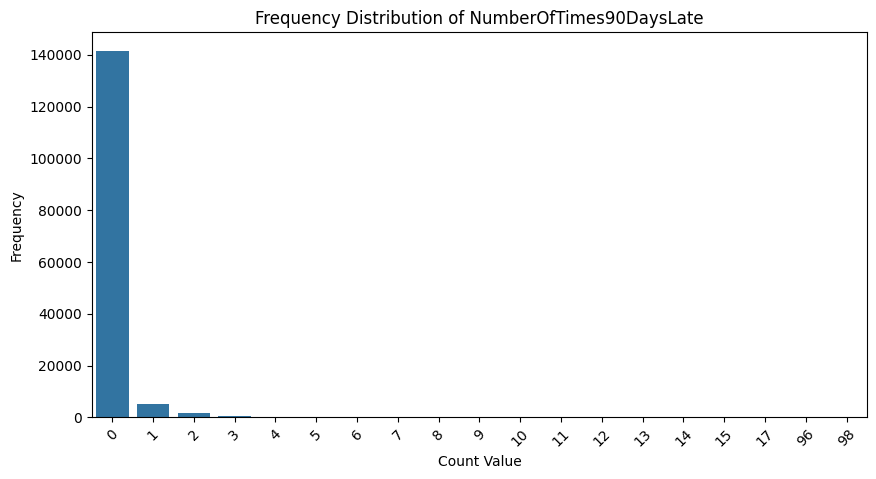

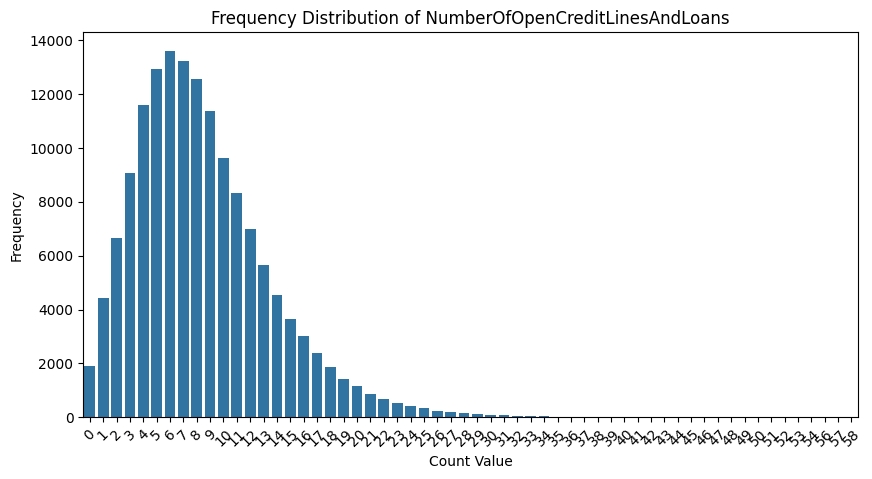

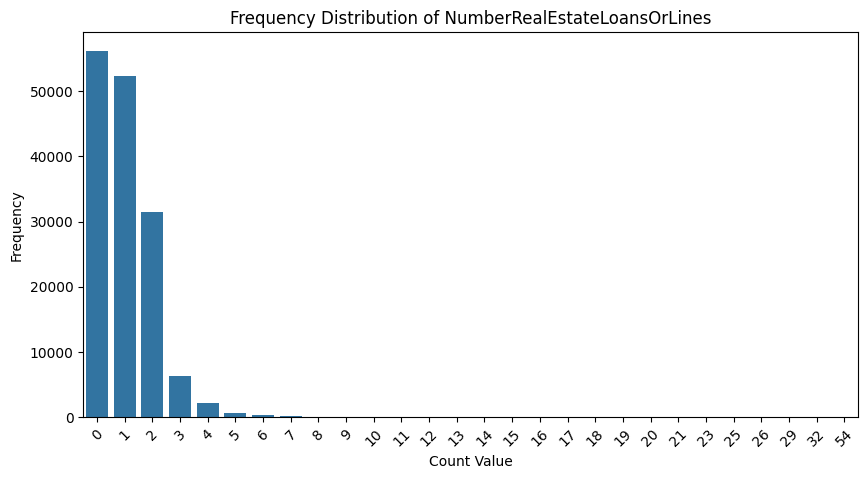

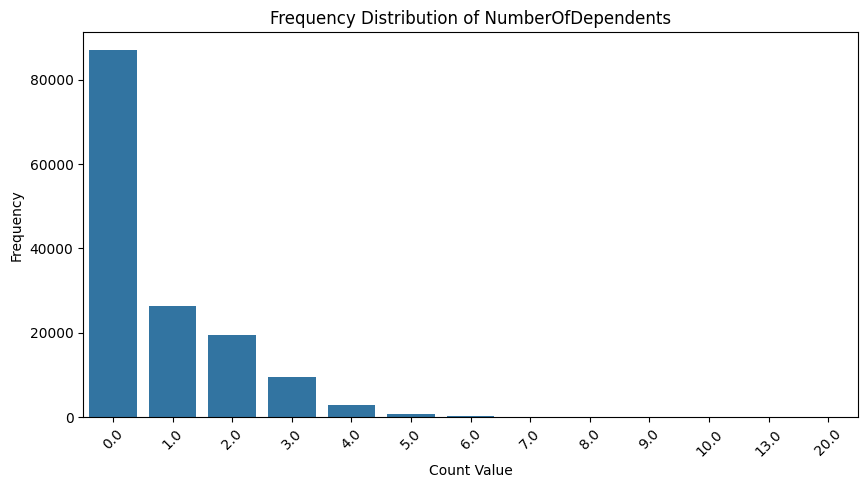

In [36]:
# Bar Charts for categorical variables frequency distributions

count_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]

for cols in count_cols:
    plt.figure(figsize=(10,5))

    vc = df[cols].value_counts().sort_index()

    sns.barplot(x=vc.index, y=vc.values)
    plt.title(f"Frequency Distribution of {cols}")
    plt.xlabel("Count Value")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()  


NumberOfTime30-59DaysPastDueNotWorse_bin
NumberOfTime30-59DaysPastDueNotWorse_bin
0               126018
1                16033
2                 4598
3+                3082
special_code       269
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse_bin
NumberOfTime60-89DaysPastDueNotWorse_bin
0               142396
1                 5731
2                 1118
3+                 486
special_code       269
Name: count, dtype: int64

NumberOfTimes90DaysLate_bin
NumberOfTimes90DaysLate_bin
0               141662
1                 5243
2                 1555
3+                1271
special_code       269
Name: count, dtype: int64

NumberOfDependents_bin
NumberOfDependents_bin
0          86902
1          26316
2          19522
3+         13336
missing     3924
Name: count, dtype: int64

NumberOfOpenCreditLinesAndLoans_bin
NumberOfOpenCreditLinesAndLoans_bin
4-8     63961
9-15    50163
0-3     22050
16+     13826
Name: count, dtype: int64

NumberRealEstateLoansOrLines_bin
NumberRe

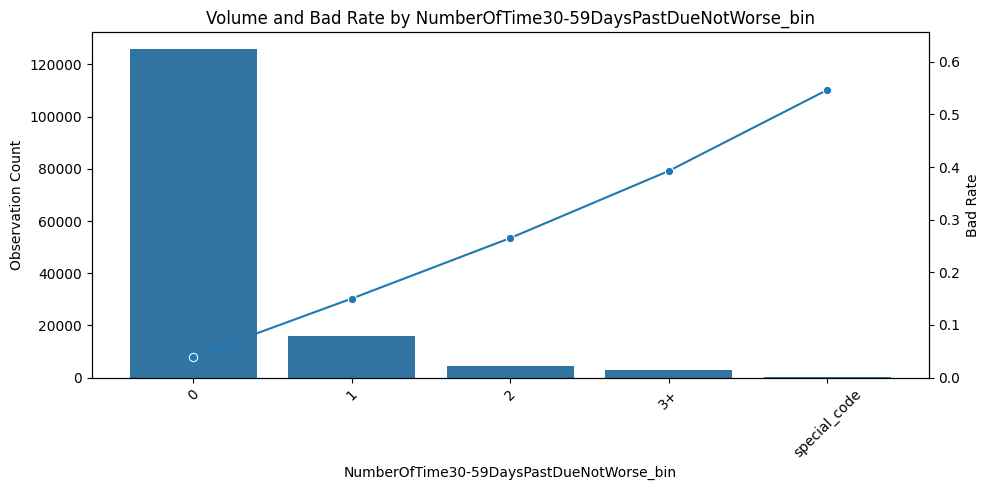

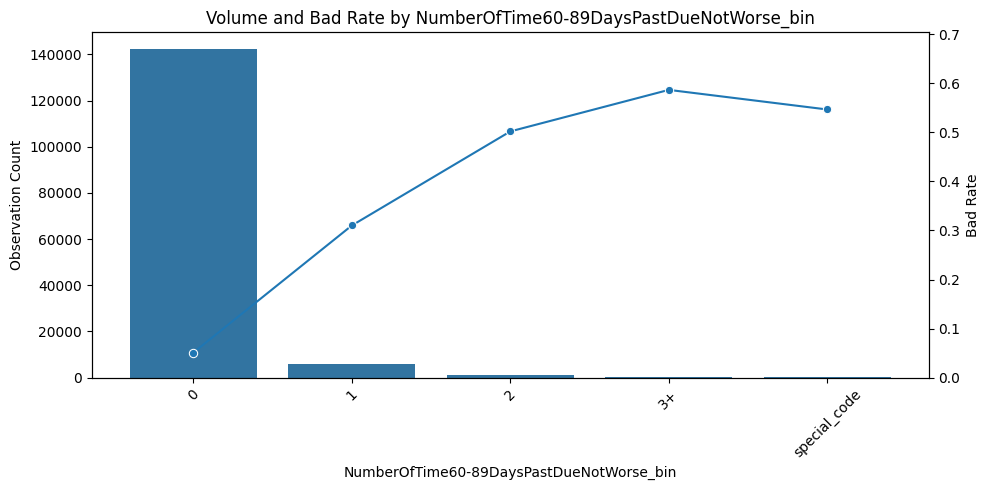

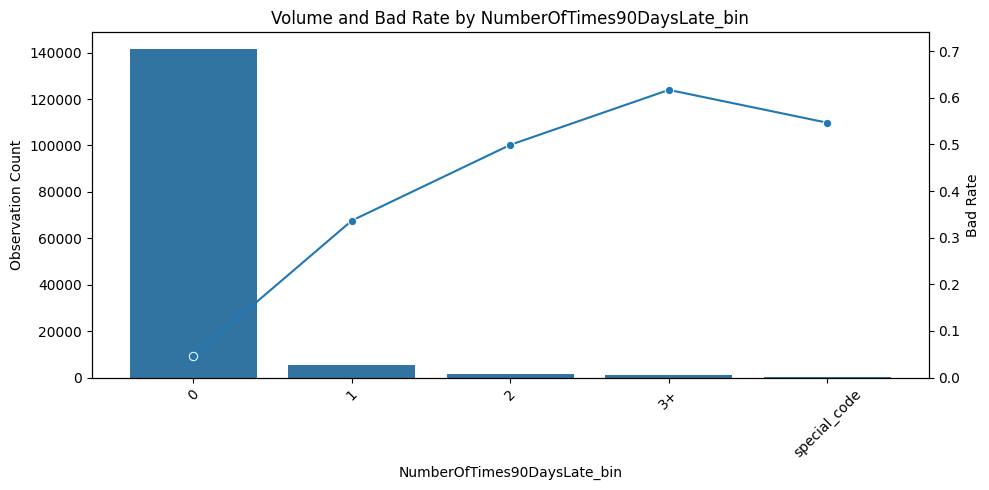

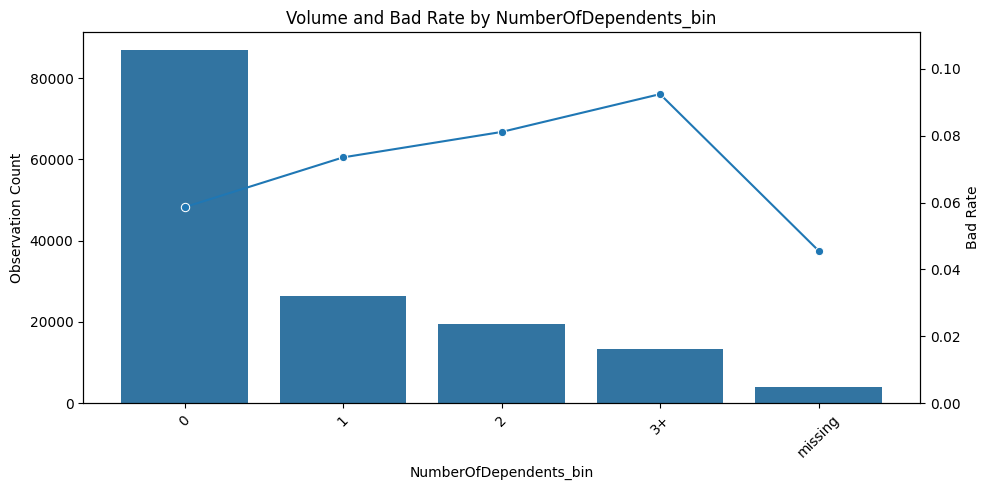

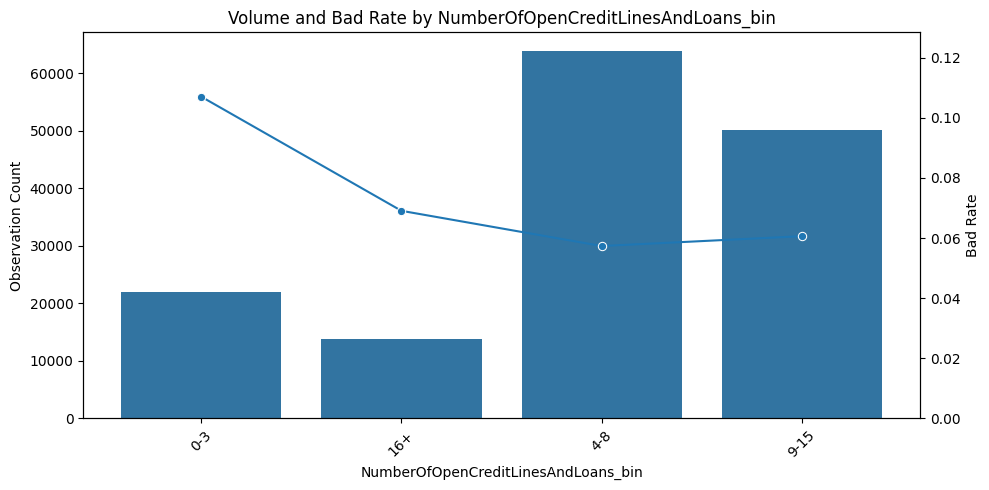

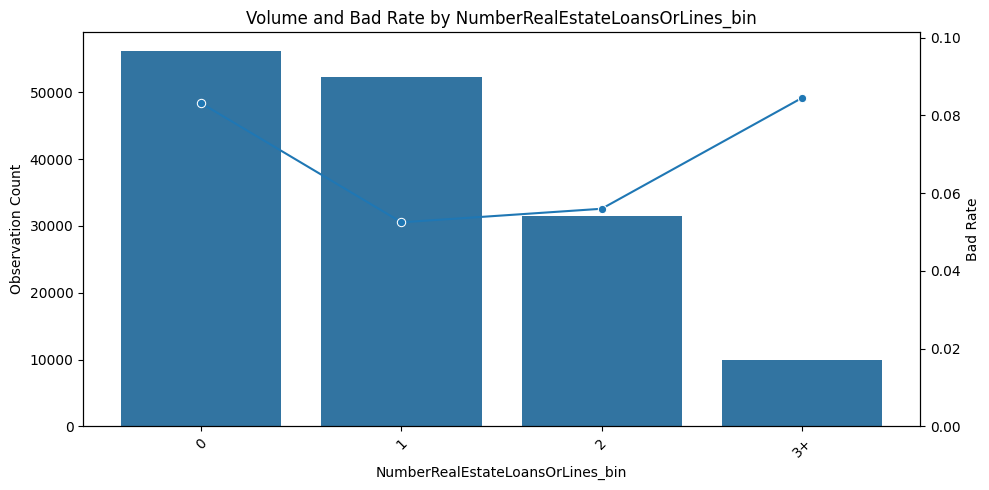

In [ ]:
# Binned categorical variable creation + NaN-safe summary + charts

df_binned = df.copy()

# Bin delinquency variables with special code handling

delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_cols:

    df_binned[col + "_bin"] = np.select(
        [
            df_binned[col].isin([96, 98]),
            df_binned[col] == 0,
            df_binned[col] == 1,
            df_binned[col] == 2,
            df_binned[col] >= 3
        ],
        [
            "special_code",
            "0",
            "1",
            "2",
            "3+"
        ],
        default="unknown"
    )

# Bin number of dependents

df_binned["NumberOfDependents_bin"] = np.select(
    [
        df_binned["NumberOfDependents"].isna(),
        df_binned["NumberOfDependents"] == 0,
        df_binned["NumberOfDependents"] == 1,
        df_binned["NumberOfDependents"] == 2,
        df_binned["NumberOfDependents"] >= 3
    ],
    [
        "missing",
        "0",
        "1",
        "2",
        "3+"
    ],
    default="unknown"
)

# Bin number of open credit lines and loans

df_binned["NumberOfOpenCreditLinesAndLoans_bin"] = pd.cut(
    df_binned["NumberOfOpenCreditLinesAndLoans"],
    bins=[-1, 3, 8, 15, np.inf],
    labels=["0-3", "4-8", "9-15", "16+"],
    include_lowest=True
).astype("object").fillna("unknown")

# Bin number of real estate loans or lines

df_binned["NumberRealEstateLoansOrLines_bin"] = np.select(
    [
        df_binned["NumberRealEstateLoansOrLines"] == 0,
        df_binned["NumberRealEstateLoansOrLines"] == 1,
        df_binned["NumberRealEstateLoansOrLines"] == 2,
        df_binned["NumberRealEstateLoansOrLines"] >= 3
    ],
    [
        "0",
        "1",
        "2",
        "3+"
    ],
    default="unknown"
)

# Column list for summary and charts

binned_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse_bin",
    "NumberOfTime60-89DaysPastDueNotWorse_bin",
    "NumberOfTimes90DaysLate_bin",
    "NumberOfDependents_bin",
    "NumberOfOpenCreditLinesAndLoans_bin",
    "NumberRealEstateLoansOrLines_bin"
]

# Ensure binned columns are treated as categorical and handle any remaining NaNs

for col in binned_cols:
    df_binned[col] = df_binned[col].astype("object").fillna("unknown")

# Review binned variable distributions

for col in binned_cols:
    print("=" * 60)
    print(col)
    print(df_binned[col].value_counts(dropna=False))
    print()

# Create summary table of binned variables vs target variable with NaN-safe handling

all_bin_summaries = []

for col in binned_cols:

    stats = (
        df_binned
        .groupby(col)["SeriousDlqin2yrs"]
        .agg(
            observations="count",
            bad_rate="mean"
        )
        .reset_index()
    )

    stats["bad_rate_pct"] = stats["bad_rate"] * 100
    stats["variable"] = col

    all_bin_summaries.append(stats)

bin_summary_df = pd.concat(all_bin_summaries, ignore_index=True)

print(bin_summary_df)

# Create combined bar and line charts for each binned variable showing observation counts and bad rates

for col in binned_cols:

    stats = (
        df_binned
        .groupby(col)["SeriousDlqin2yrs"]
        .agg(
            observations="count",
            bad_rate="mean"
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(10,5))

    sns.barplot(
        data=stats,
        x=col,
        y="observations",
        ax=ax1
    )

    ax1.set_ylabel("Observation Count")
    ax1.set_xlabel(col)
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()

    sns.lineplot(
        data=stats,
        x=col,
        y="bad_rate",
        marker="o",
        sort=False,
        ax=ax2
    )

    ax2.set_ylabel("Bad Rate")
    ax2.set_ylim(0, max(stats["bad_rate"].max() * 1.20, 0.10))

    plt.title(f"Volume and Bad Rate by {col}")
    plt.tight_layout()
    plt.show()

## Predictive EDA – Binned Count Variables

Raw count variables were transformed into grouped buckets prior to interpretation. This was done to improve statistical stability, reduce sparse-tail noise, and create borrower segments that are easier to explain operationally and model consistently.

Using raw values such as 17 dependents, 54 credit lines, or 98 delinquency events can create unstable event-rate estimates because those values often contain very few observations. Binning combines adjacent values into economically meaningful groups with adequate sample sizes.

This approach is standard in credit risk modeling, scorecard development, and model risk management because it improves interpretability, monotonicity testing, and downstream logistic regression stability.

---

## 1. NumberOfTime30-59DaysPastDueNotWorse

### Binning Logic

Buckets used:

- 0
- 1
- 2
- 3+
- special_code (96 / 98)

### Why This Structure Was Chosen

- Zero delinquency is materially different from any delinquency history.
- One late payment often reflects an early warning signal.
- Two late payments indicate repeat repayment stress.
- Three or more indicates persistent repayment weakness.
- 96 / 98 values are likely bureau/system codes rather than true counts and therefore separated.

Alternative binning such as 0 / 1-2 / 3+ would be simpler but would lose granularity between first and second delinquency events.

### Observed Relationship

Bad rate rose strongly and monotonically:

- 0 = 4.0%
- 1 = 15.0%
- 2 = 26.5%
- 3+ = 39.3%
- special_code = 54.6%

### Interpretation

Recent moderate delinquency history is one of the strongest signals of future serious delinquency. Even one prior event materially increases risk, while repeated events sharply worsen borrower outlook.

This variable is likely a top-tier predictor.

---

## 2. NumberOfTime60-89DaysPastDueNotWorse

### Binning Logic

Buckets used:

- 0
- 1
- 2
- 3+
- special_code

Same logic as above.

### Observed Relationship

- 0 = 5.1%
- 1 = 31.0%
- 2 = 50.2%
- 3+ = 58.6%
- special_code = 54.6%

### Interpretation

More severe delinquency (60–89 days late) carries even stronger predictive power than shorter lateness windows. Once a borrower reaches this stage, future serious default probability rises dramatically.

This is likely among the strongest variables in the dataset.

---

## 3. NumberOfTimes90DaysLate

### Binning Logic

Buckets used:

- 0
- 1
- 2
- 3+
- special_code

90+ day delinquency is a major distress event, so preserving low-count granularity is useful.

### Observed Relationship

- 0 = 4.6%
- 1 = 33.7%
- 2 = 49.9%
- 3+ = 61.7%
- special_code = 54.6%

### Interpretation

This variable captures severe repayment failure. A borrower with any prior 90+ day delinquency is substantially riskier than one with none. Multiple occurrences indicate chronic distress.

Extremely strong candidate for final model inclusion.

---

## 4. NumberOfDependents

### Binning Logic

Buckets used:

- 0
- 1
- 2
- 3+
- missing

### Why This Structure Was Chosen

Dependents tend to cluster at low values. Tail values such as 7, 10, or 20 are sparse and less reliable statistically. Grouping 3+ preserves larger-family burden without over-fragmenting rare categories.

Missing values were isolated rather than imputed immediately to test whether missingness itself carries signal.

### Observed Relationship

- 0 = 5.9%
- 1 = 7.4%
- 2 = 8.1%
- 3+ = 9.2%
- missing = 4.6%

### Interpretation

There is a moderate upward relationship between family obligations and delinquency risk. Larger dependent burden may reduce disposable income and financial flexibility.

This is a useful secondary control variable rather than a primary risk driver.

---

## 5. NumberOfOpenCreditLinesAndLoans

### Binning Logic

Buckets used:

- 0-3
- 4-8
- 9-15
- 16+

### Why This Structure Was Chosen

This variable has a wider numeric range and reflects credit depth rather than distress. Natural segmentation was created around:

- low/thin-file borrowers
- mainstream borrowers
- experienced/high-credit borrowers
- very high exposure borrowers

Using single-value buckets would create unnecessary noise.

### Observed Relationship

- 0-3 = 10.7%
- 4-8 = 5.7%
- 9-15 = 6.1%
- 16+ = 6.9%

### Interpretation

Borrowers with very few open lines appear riskiest, likely reflecting thin credit files or limited established borrowing history.

Moderate credit participation appears healthiest.

Very high counts may reintroduce leverage complexity, creating a mild U-shaped risk pattern.

This variable may be valuable as a structural profile indicator.

---

## 6. NumberRealEstateLoansOrLines

### Binning Logic

Buckets used:

- 0
- 1
- 2
- 3+

### Why This Structure Was Chosen

Values are concentrated at lower counts. Ownership and mortgage exposure often change borrower behavior materially between zero, one, and multiple secured obligations.

### Observed Relationship

- 0 = 8.3%
- 1 = 5.3%
- 2 = 5.6%
- 3+ = 8.5%

### Interpretation

Borrowers with no real estate exposure may be less established or less wealthy, while borrowers with one or two real estate facilities appear lower risk.

Three or more may reflect leverage complexity, investment properties, or debt burden.

Another nonlinear/U-shaped relationship is present.

---

## Overall Conclusions

1. Historical delinquency variables are the strongest raw predictors in the dataset.
2. Structural credit-profile variables (open lines, real estate loans) show nonlinear relationships and may require binning rather than raw linear treatment.
3. Household burden (dependents) shows moderate but intuitive risk lift.
4. Binning substantially improved interpretability compared with raw count-value charts.

## Modeling Implications

Recommended next-stage treatment:

- Delinquency variables: strong inclusion candidates
- Open lines / real estate loans: binned or nonlinear treatment preferred
- Dependents: control variable candidate
- Special codes: review separately in preprocessing


In [41]:
(df["age"] == 0).sum()

np.int64(1)

/var/folders/bk/_22dcwfd3dq1p5j4s4rr5xfw0000gn/T/ipykernel_55701/3380389898.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cont.groupby(col)["SeriousDlqin2yrs"]


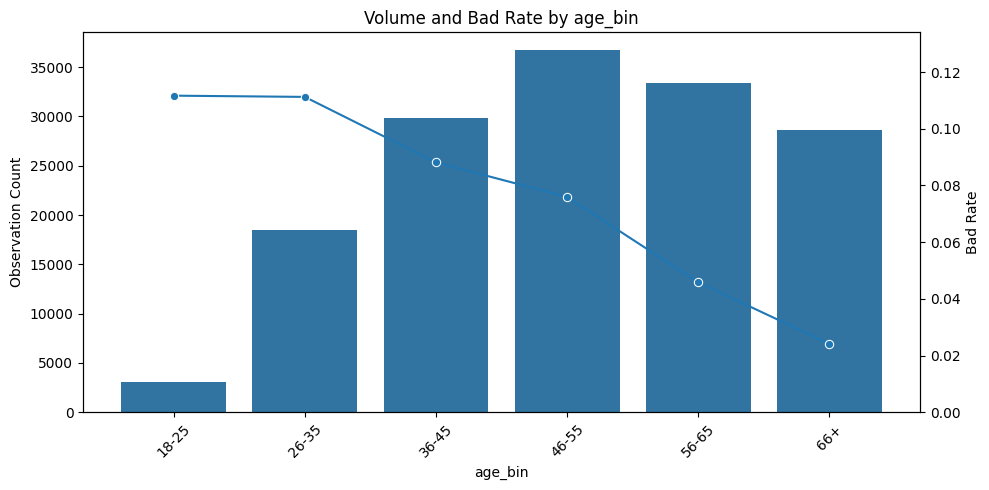

/var/folders/bk/_22dcwfd3dq1p5j4s4rr5xfw0000gn/T/ipykernel_55701/3380389898.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cont.groupby(col)["SeriousDlqin2yrs"]


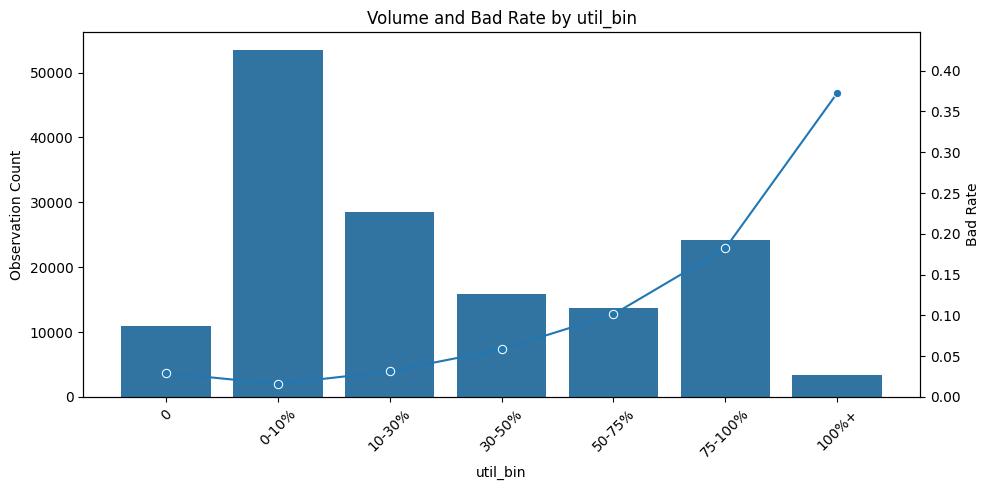

/var/folders/bk/_22dcwfd3dq1p5j4s4rr5xfw0000gn/T/ipykernel_55701/3380389898.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cont.groupby(col)["SeriousDlqin2yrs"]


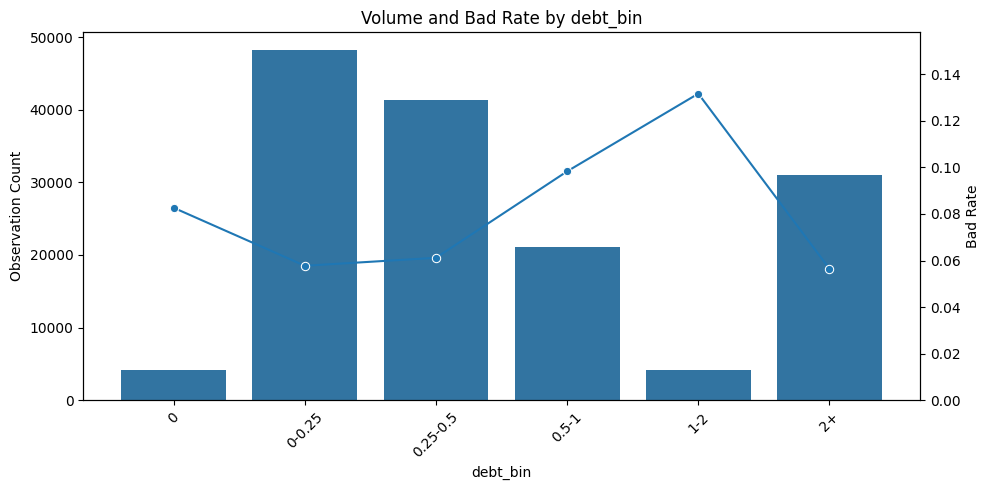

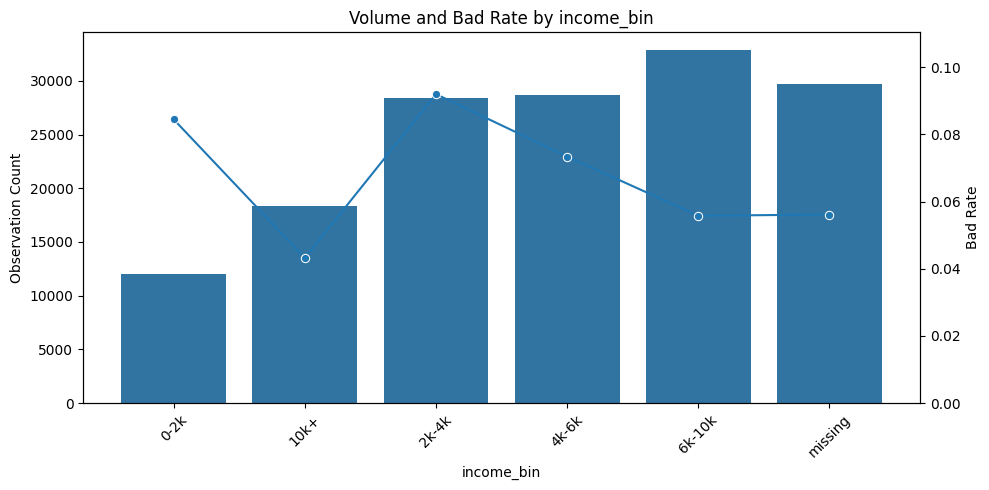

In [7]:
# EDA with binned variables and NaN-safe summaries + charts for continuous variables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_cont = df.copy()

# Remove invalid age values (age = 0) before binning

df_cont = df_cont[df_cont["age"] > 0]

# Preliminary Age Binning

df_cont["age_bin"] = pd.cut(
    df_cont["age"],
    bins=[17,25,35,45,55,65,120],
    labels=["18-25","26-35","36-45","46-55","56-65","66+"]
)

# Revolving Utilization of Unsecured Lines Binning

df_cont["util_bin"] = pd.cut(
    df_cont["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-0.001,0,0.10,0.30,0.50,0.75,1.00,np.inf],
    labels=[
        "0",
        "0-10%",
        "10-30%",
        "30-50%",
        "50-75%",
        "75-100%",
        "100%+"
    ]
)

# Debt Ratio Binning

df_cont["debt_bin"] = pd.cut(
    df_cont["DebtRatio"],
    bins=[-0.001,0,0.25,0.50,1,2,np.inf],
    labels=[
        "0",
        "0-0.25",
        "0.25-0.5",
        "0.5-1",
        "1-2",
        "2+"
    ]
)

# Monthly Income Binning with NaN handling

income = df_cont["MonthlyIncome"]

df_cont["income_bin"] = np.where(
    income.isna(), "missing",
    pd.cut(
        income,
        bins=[-0.001,2000,4000,6000,10000,np.inf],
        labels=[
            "0-2k",
            "2k-4k",
            "4k-6k",
            "6k-10k",
            "10k+"
        ]
    ).astype("object")
)

# Final column list for summary and charts

cont_cols = [
    "age_bin",
    "util_bin",
    "debt_bin",
    "income_bin"
]

# Plot Volume + Bad Rate for binned continuous variables

for col in cont_cols:

    stats = (
        df_cont.groupby(col)["SeriousDlqin2yrs"]
        .agg(
            observations="count",
            bad_rate="mean"
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(10,5))

    sns.barplot(
        data=stats,
        x=col,
        y="observations",
        ax=ax1
    )

    ax1.set_ylabel("Observation Count")
    ax1.set_xlabel(col)
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()

    sns.lineplot(
        data=stats,
        x=col,
        y="bad_rate",
        marker="o",
        sort=False,
        ax=ax2
    )

    ax2.set_ylabel("Bad Rate")
    ax2.set_ylim(0, max(stats["bad_rate"].max()*1.2, 0.10))

    plt.title(f"Volume and Bad Rate by {col}")
    plt.tight_layout()
    plt.show()

## Predictive EDA – Continuous Variables

Continuous variables were grouped into economically meaningful ranges to assess nonlinear relationships with serious delinquency risk. Raw continuous values often mask business patterns, whereas grouped analysis reveals risk gradients more clearly.

This analysis helps determine whether variables should be modeled linearly, transformed, winsorized, or binned in downstream preprocessing.

---
## 1. Age

### Binning Logic

Buckets used:

- 18-25
- 26-35
- 36-45
- 46-55
- 56-65
- 66+

### Why This Structure Was Chosen

Age is naturally interpreted through life-stage cohorts rather than arbitrary percentiles.

These bands reflect:

- young/thin credit history borrowers
- early prime working-age borrowers
- mature borrowers
- near-retirement borrowers

### Observed Relationship

Bad rate declines steadily with age:

- 18-25 ≈ 11%
- 26-35 ≈ 11%
- 36-45 ≈ 8.5%
- 46-55 ≈ 7.5%
- 56-65 ≈ 4.5%
- 66+ ≈ 2.5%

### Interpretation

Older borrowers exhibit materially lower delinquency risk. This is economically intuitive and likely reflects:

- more stable income
- stronger repayment history
- accumulated assets
- lower credit-seeking behavior

Age appears highly predictive and approximately monotonic.

---

## 2. Revolving Utilization of Unsecured Lines

### Binning Logic

Buckets used:

- 0
- 0-10%
- 10-30%
- 30-50%
- 50-75%
- 75-100%
- 100%+

### Why This Structure Was Chosen

Utilization is one of the most important consumer credit variables. Common lending thresholds occur around 30%, 50%, 75%, and 100%.

Using these thresholds is more meaningful than percentile cuts.

### Observed Relationship

Bad rate rises sharply with utilization:

- 0-10% = lowest risk
- 10-30% = modest increase
- 30-75% = accelerating risk
- 75-100% = high risk
- 100%+ = extreme risk (~37%)

### Interpretation

High utilization likely indicates liquidity stress, over-extension, or inability to pay balances down.

This variable is expected to be among the strongest model predictors.

---

## 3. Debt Ratio

### Binning Logic

Buckets used:

- 0
- 0-0.25
- 0.25-0.5
- 0.5-1
- 1-2
- 2+

### Why This Structure Was Chosen

Debt ratio reflects leverage burden. Ratios below 1 generally imply manageable obligations relative to income, while values above 1 may indicate heavy leverage or unstable denominator effects.

### Observed Relationship

Risk rises through middle leverage bands:

- 0-0.25 = lower risk
- 0.25-0.5 = similar low risk
- 0.5-1 = elevated risk
- 1-2 = highest observed risk
- 2+ declines unexpectedly

### Interpretation

The decline in the 2+ bucket likely reflects data distortion from zero/low income denominators rather than genuinely safer borrowers.

DebtRatio requires careful preprocessing and likely winsorization/log transformation.

This variable should not be accepted raw without treatment.

---

## 4. Monthly Income

### Binning Logic

Buckets used:

- 0-2k
- 2k-4k
- 4k-6k
- 6k-10k
- 10k+
- missing

### Why This Structure Was Chosen

Income is naturally interpreted through affordability bands rather than percentiles. These ranges approximate low, moderate, upper-middle, and high household earnings.

Missing values were isolated to test informational content.

### Observed Relationship

General pattern:

- lower income = higher risk
- higher income = lower risk

However:

- 2k-4k showed elevated risk
- missing income performed similarly to higher-income groups

### Interpretation

Income is predictive but not perfectly monotonic in raw form. This often occurs because income interacts with utilization, debt burden, household size, and reporting quality.

Missing income may reflect self-employed or nontraditional reporting rather than purely distressed borrowers.

Income remains useful but may perform better after imputation and transformation.

---

## Overall Conclusions

1. Age shows strong monotonic improvement with borrower maturity.
2. Utilization is one of the clearest risk drivers in the dataset.
3. DebtRatio contains predictive signal but also likely denominator distortion.
4. Income is directionally useful but may require preprocessing to unlock full value.

## Modeling Implications

Recommended next-stage treatment:

- Age: include directly or binned
- Utilization: winsorize/log/binned candidate
- DebtRatio: transform and cap before use
- MonthlyIncome: impute + transform/log candidate

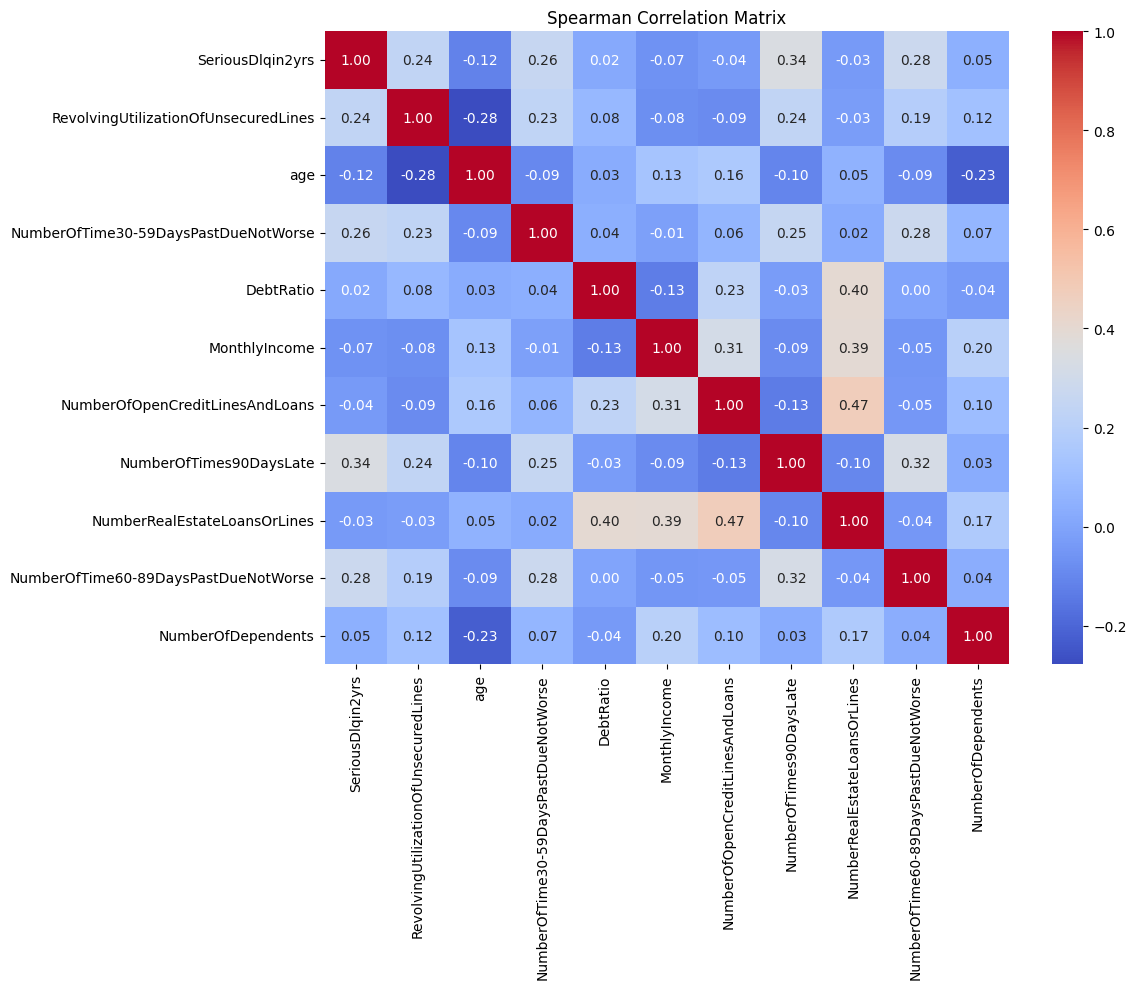

In [10]:
# Correlation matrix analysis for continuous and count variables (Spearman correlation for monotonic relationships and robustness to outliers)

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr(method="spearman")

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()  
plt.show()  

## Spearman Correlation Review

Spearman correlation broadly confirmed prior univariate findings.

Historical delinquency variables and revolving utilization displayed the strongest positive associations with serious delinquency.

Age and MonthlyIncome were negatively associated with default risk, indicating safer performance among older and higher-income borrowers.

Moderate correlation existed among credit-structure variables such as open credit lines, real estate loans, and income, suggesting shared borrower profile characteristics but not extreme redundancy.